# Monoclonal Antibody (mAb) Titer Prediction on Actual Test Set

**Note:** `datahow_interview_test_targets-TEMPLATE.csv` is a *submission template*, not the real ground truth - every row currently has the same placeholder value (`Y:Titer = 2000`). 

In [1]:
import pathlib

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
DATA_DIR = "../data"
MODELS_DIR = pathlib.Path("../models")

test_exp = pd.read_csv(f"{DATA_DIR}/test_exp_features.csv", index_col="Exp")
feature_cols = [c for c in test_exp.columns if c != "n_days"]

# to be replaced with the actual test file
targets = pd.read_csv(
    f"{DATA_DIR}/datahow_interview_test_targets-TEMPLATE.csv", index_col="Exp"
)

print("test_exp:", test_exp.shape)
print(f"Using {len(feature_cols)} features")
# test_exp.head()

test_exp: (20, 68)
Using 67 features


## 1. Load trained models

Load the trained regressors from `models` folder that were fit on the full training set and persisted with `joblib` in `baseline.ipynb`.

In [3]:
model_files = {
    "Linear Regression": "LR.joblib",
    "Multiple Linear Regression Top 5": "MLR_Top5.joblib",
    "Multiple Linear Regression All Features": "MLR.joblib",
    "Ridge": "Ridge.joblib",
    "PLS (5 comp)": "PLS_5.joblib",
    "RandomForest": "RF.joblib",
    "GradientBoosting": "GradientBoosting.joblib",
    "XGBoost": "XGBoost.joblib",
}
models = {name: joblib.load(MODELS_DIR / fname) for name, fname in model_files.items()}
list(models.keys())

['Linear Regression',
 'Multiple Linear Regression Top 5',
 'Multiple Linear Regression All Features',
 'Ridge',
 'PLS (5 comp)',
 'RandomForest',
 'GradientBoosting',
 'XGBoost']

## 2. Generate predictions and compare againt target reference (template)

- Only the simple `Linear Regression` model was trained on a single feature (`VCD_time_to_peak`)
- Every other model was trained on the full 67-feature set, in the same column order as the training data.

In [4]:
X_full = test_exp[feature_cols]

best_5_features = [
    "VCD_time_to_peak",
    "Lysed_slope",
    "Lysed_final",
    "Lysed_max",
    "Lysed_mean",
]

X_top5 = test_exp[best_5_features].to_numpy()
X_best = X_top5[:, 0].reshape(-1, 1)

predictions = {}
for name, model in models.items():
    if name == "Linear Regression":
        X_input = X_best
    elif name == "Multiple Linear Regression Top 5":
        X_input = X_top5
    else:
        X_input = X_full
    predictions[name] = model.predict(X_input).ravel()

pred_df = pd.DataFrame(predictions, index=test_exp.index)
comparison = pred_df.copy()
comparison["Y:Titer (template)"] = targets["Y:Titer"]
comparison

/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but GradientBoostingRe

,Linear Regression,Multiple Linear Regression Top 5,Multiple Linear Regression All Features,Ridge,PLS (5 comp),RandomForest,GradientBoosting,XGBoost,Y:Titer (template)
Exp,,,,,,,,,
Test Exp 1,2289.087043,2336.536529,1061.592795,2244.114978,2448.794105,2418.263770,2509.959303,2293.958008,2000
Test Exp 2,1592.958634,1955.415810,2900.113900,3141.410235,3272.292260,2796.485769,2665.466782,1918.859863,2000
Test Exp 3,3333.279656,2799.729992,1529.447957,1691.717985,1629.647278,1778.933114,1566.297806,1513.252319,2000
Test Exp 4,1244.894430,3078.348770,1093.657678,3237.390518,3279.233141,2124.092275,1784.833250,1823.567627,2000
Test Exp 5,2637.151247,2873.162760,2700.222534,2966.109617,2947.580346,2861.809514,2495.654484,2495.306641,2000
Test Exp 6,1244.894430,1608.995917,2017.469478,1986.081918,1875.963297,1424.966912,1014.158288,1036.974854,2000
Test Exp 7,2637.151247,3205.901036,2292.121234,3485.188230,3370.437716,2865.793002,2447.467612,2568.235840,2000
Test Exp 8,548.766021,1852.265781,-431.155307,1905.684499,2013.974128,2026.095769,1698.440836,1393.233887,2000
Test Exp 9,896.830225,709.048890,-1391.552768,-542.000928,-405.107920,565.055023,590.504182,523.913025,2000


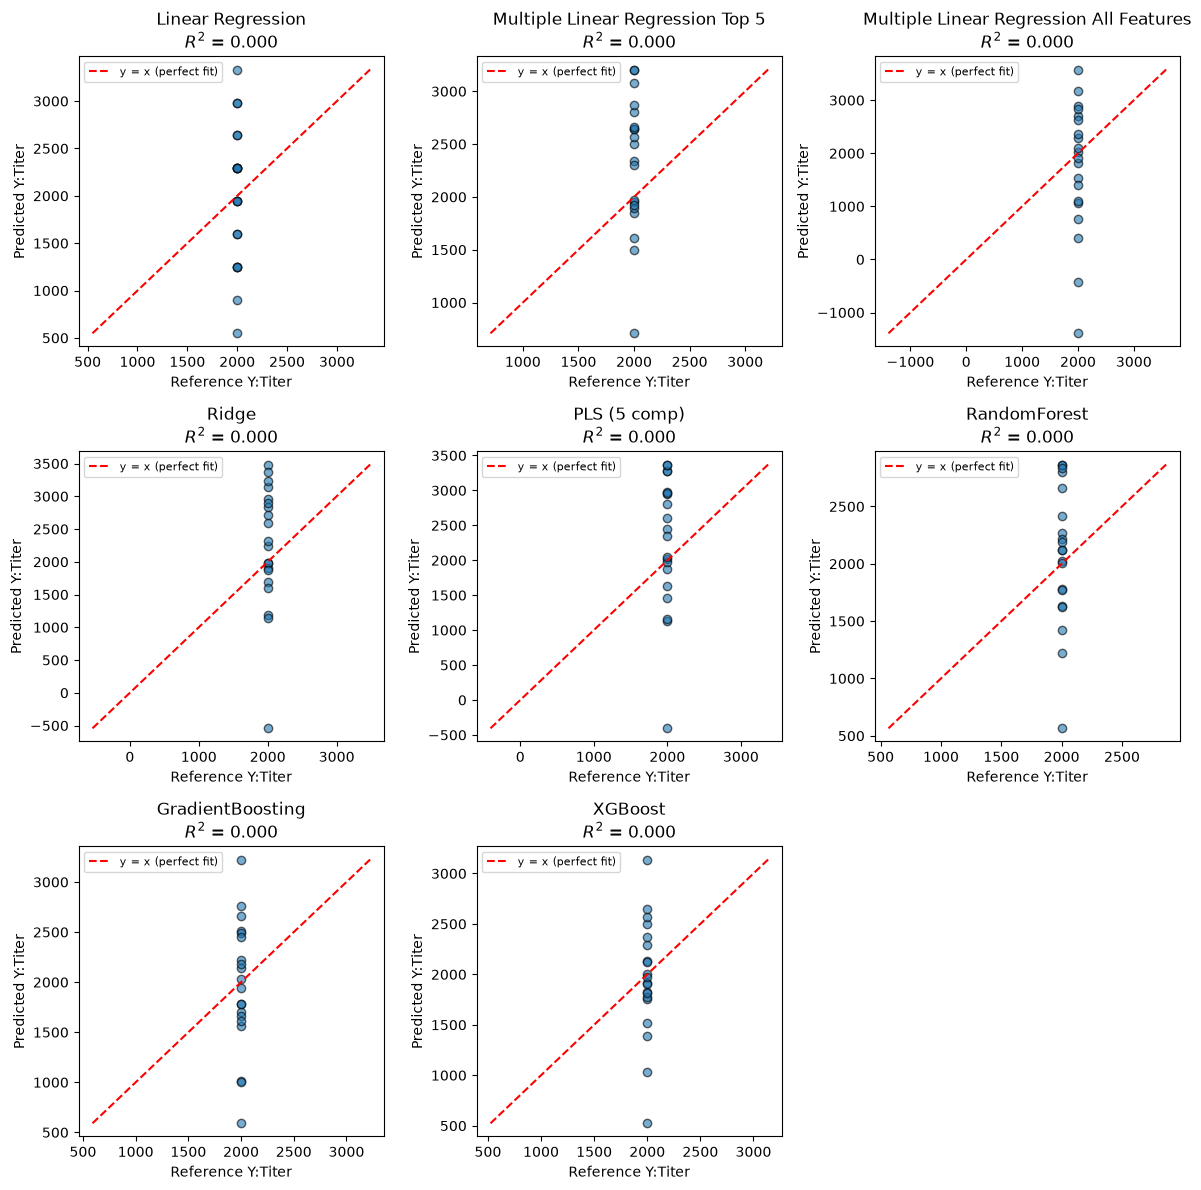

In [5]:
y_true = targets["Y:Titer"].loc[pred_df.index]

n_models = len(pred_df.columns)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, pred_df.columns):
    y_pred = pred_df[name]
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolor="k")

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", label="y = x (perfect fit)")

    ax.set_xlabel("Reference Y:Titer")
    ax.set_ylabel("Predicted Y:Titer")
    ax.set_title(f"{name}\n$R^2$ = {r2:.3f}")
    ax.legend(fontsize=8)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
y_true = targets["Y:Titer"].loc[pred_df.index]

metrics = []
for name in pred_df.columns:
    y_pred = pred_df[name]
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    rrmse = rmse / np.mean(y_true)
    metrics.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": rmse,
            "RRMSE": rrmse,
            "R2": r2_score(y_true, y_pred),
        }
    )

print("Model performance on test set (sorted by metrics)")
metrics_df = pd.DataFrame(metrics).sort_values("MAE").reset_index(drop=True)
metrics_df

Model performance on test set (sorted by metrics)


,model,MAE,RMSE,RRMSE,R2
0,XGBoost,416.752502,567.674906,0.283837,0.0
1,RandomForest,468.645936,591.256098,0.295628,0.0
2,GradientBoosting,501.425915,629.280686,0.314640,0.0
3,Multiple Linear Regression Top 5,569.963253,693.389647,0.346695,0.0
4,Linear Regression,591.709147,718.475148,0.359238,0.0
5,Ridge,748.950026,963.057223,0.481529,0.0
6,PLS (5 comp),781.105077,969.734868,0.484867,0.0
7,Multiple Linear Regression All Features,921.788020,1230.905114,0.615453,0.0


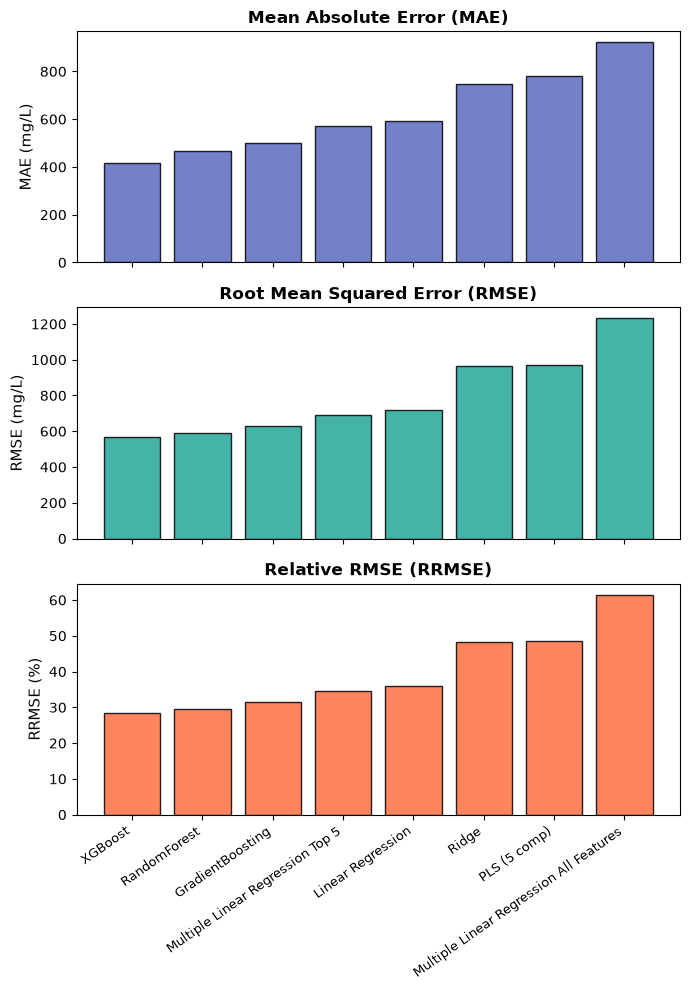

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)

# 1. Mean Absolute Error (MAE)
axes[0].bar(
    metrics_df["model"],
    metrics_df["MAE"],
    color="#5c6bc0",
    edgecolor="black",
    alpha=0.85,
)
axes[0].set_ylabel("MAE (mg/L)", fontsize=11)
axes[0].set_title("Mean Absolute Error (MAE)", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(len(metrics_df)))
axes[0].set_xticklabels(metrics_df["model"], rotation=35, ha="right", fontsize=9.5)

# 2. Root Mean Squared Error (RMSE)
axes[1].bar(
    metrics_df["model"],
    metrics_df["RMSE"],
    color="#26a69a",
    edgecolor="black",
    alpha=0.85,
)
axes[1].set_ylabel("RMSE (mg/L)", fontsize=11)
axes[1].set_title("Root Mean Squared Error (RMSE)", fontsize=12, fontweight="bold")
axes[1].set_xticks(range(len(metrics_df)))
axes[1].set_xticklabels(metrics_df["model"], rotation=35, ha="right", fontsize=9.5)

# 3. Relative RMSE (RRMSE)
axes[2].bar(
    metrics_df["model"],
    metrics_df["RRMSE"] * 100,
    color="#ff7043",
    edgecolor="black",
    alpha=0.85,
)
axes[2].set_ylabel("RRMSE (%)", fontsize=11)
axes[2].set_title("Relative RMSE (RRMSE)", fontsize=12, fontweight="bold")
axes[2].set_xticks(range(len(metrics_df)))
axes[2].set_xticklabels(metrics_df["model"], rotation=35, ha="right", fontsize=9.5)

plt.tight_layout()
plt.show()

For **RMSE** metric, the rule of thumb is that:

- $\text{RMSE} < 0.5 \times \sigma_y$: Excellent model ($R^2 > 0.75$)
- $\text{RMSE} \approx 0.6-0.7 \times \sigma_y$: 
  - Good ensemble model (GradientBoosting, RandomForest, XGBoost)
- $\text{RMSE} \ge \sigma_y$: Model performs worse than simply predicting the dataset mean.

where $\sigma_y$ is the Standard Deviation of the target variable ($y$) 

From research, the rule of thumb for **Relative RMSE (RRMSE)** (%) metric:

- $\text{RRMSE} < 10%$: Excellent accuracy
- $10% \le \text{RRMSE} < 20%$: Good accuracy
- $20% \le \text{RRMSE} \le 30%$: Fair / Acceptable (where tree ensembles fall on this small $N=100$ dataset)
- $\text{RRMSE} > 30%$: Poor accuracy (where unregularized linear models land)